In [1]:
import pandas as pd

df = pd.read_csv("diamonds.csv")
print("Original shape:", df.shape)

Original shape: (50000, 10)


In [2]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    50000 non-null  float64
 1   cut      50000 non-null  object 
 2   color    50000 non-null  object 
 3   clarity  50000 non-null  object 
 4   depth    50000 non-null  float64
 5   table    50000 non-null  float64
 6   price    50000 non-null  int64  
 7   x        50000 non-null  float64
 8   y        50000 non-null  float64
 9   z        50000 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 3.8+ MB


carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

In [3]:
df = df[(df["x"] > 0) & (df["y"] > 0) & (df["z"] > 0)]
print("Shape after removing zero-dimension rows:", df.shape)

Shape after removing zero-dimension rows: (49983, 10)


In [4]:
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Duplicate rows: 126
Shape after removing duplicates: (49857, 10)


In [5]:
cut_order = {"Fair": 1, "Good": 2, "Very Good": 3, "Premium": 4, "Ideal": 5}
color_order = {"J": 1, "I": 2, "H": 3, "G": 4, "F": 5, "E": 6, "D": 7}
clarity_order = {
    "I1": 1, "SI2": 2, "SI1": 3, "VS2": 4,
    "VS1": 5, "VVS2": 6, "VVS1": 7, "IF": 8
}

In [6]:
df["cut_encoded"] = df["cut"].map(cut_order)
df["color_encoded"] = df["color"].map(color_order)
df["clarity_encoded"] = df["clarity"].map(clarity_order)

In [ ]:
df = df.drop(columns=["cut", "color", "clarity"])

In [7]:
print(df.head())
print("Final shape:", df.shape)
print(df.dtypes)

   carat      cut color clarity  depth  table  price     x     y     z  \
0   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98  2.43   
1   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84  2.31   
2   0.23     Good     E     VS1   56.9   65.0    327  4.05  4.07  2.31   
3   0.29  Premium     I     VS2   62.4   58.0    334  4.20  4.23  2.63   
4   0.31     Good     J     SI2   63.3   58.0    335  4.34  4.35  2.75   

   cut_encoded  color_encoded  clarity_encoded  
0            5              6                2  
1            4              6                3  
2            2              6                5  
3            4              2                4  
4            2              1                2  
Final shape: (49857, 13)
carat              float64
cut                 object
color               object
clarity             object
depth              float64
table              float64
price                int64
x                  float64
y                  f

In [8]:
df.to_csv("diamonds_cleaned.csv", index=False)
print("Cleaned data saved as diamonds_cleaned.csv")

Cleaned data saved as diamonds_cleaned.csv


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df = pd.read_csv("diamonds_cleaned.csv")
print(df.shape)
df.head()

(49857, 13)


,carat,cut,color,clarity,depth,table,price,x,y,z,cut_encoded,color_encoded,clarity_encoded
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43,5,6,2
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31,4,6,3
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31,2,6,5
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63,4,2,4
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75,2,1,2


In [11]:
df.describe()

,carat,depth,table,price,x,y,z,cut_encoded,color_encoded,clarity_encoded
count,49857.000000,49857.000000,49857.000000,49857.000000,49857.000000,49857.000000,49857.000000,49857.000000,49857.000000,49857.000000
mean,0.799101,61.751884,57.458521,3943.651042,5.734907,5.738407,3.542236,3.902742,4.401669,4.048880
std,0.474403,1.427981,2.230608,3994.952489,1.120144,1.143127,0.703695,1.116179,1.700745,1.643196
min,0.200000,43.000000,43.000000,326.000000,3.730000,3.680000,1.070000,1.000000,1.000000,1.000000
25%,0.400000,61.000000,56.000000,952.000000,4.720000,4.720000,2.910000,3.000000,3.000000,3.000000
50%,0.700000,61.800000,57.000000,2411.000000,5.700000,5.710000,3.530000,4.000000,4.000000,4.000000
75%,1.040000,62.500000,59.000000,5351.000000,6.540000,6.540000,4.040000,5.000000,6.000000,5.000000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000,5.000000,7.000000,8.000000


In [12]:
df["volume"] = df["x"] * df["y"] * df["z"]

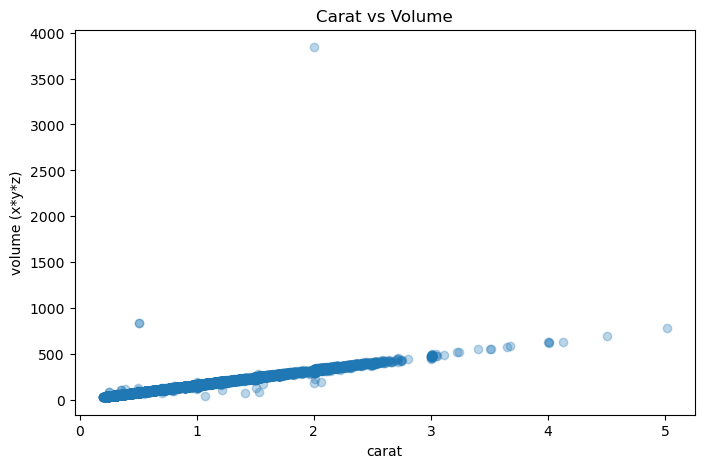

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(df["carat"], df["volume"], alpha=0.3)
plt.xlabel("carat")
plt.ylabel("volume (x*y*z)")
plt.title("Carat vs Volume")
plt.show()

In [14]:
df.sort_values("volume", ascending=False).head(10)

,carat,cut,color,clarity,depth,table,price,x,y,z,cut_encoded,color_encoded,clarity_encoded,volume
22241,2.00,Premium,H,SI2,58.9,57.0,12210,8.09,58.90,8.06,4,3,2,3840.598060
44702,0.51,Very Good,E,VS1,61.8,54.7,1970,5.12,5.15,31.80,3,6,5,838.502400
45427,0.51,Ideal,E,VS1,61.8,55.0,2075,5.15,31.80,5.12,5,6,5,838.502400
25360,5.01,Fair,J,I1,65.5,59.0,18018,10.74,10.54,6.98,1,1,1,790.133208
25554,4.50,Fair,J,I1,65.8,58.0,18531,10.23,10.16,6.72,1,1,1,698.455296
25097,4.13,Fair,H,I1,64.8,61.0,17329,10.00,9.85,6.43,1,3,1,633.355000
24043,4.01,Premium,I,I1,61.0,61.0,15223,10.14,10.10,6.17,4,2,1,631.894380
24466,4.00,Very Good,I,I1,63.3,58.0,15984,10.01,9.94,6.31,3,2,1,627.841214
24044,4.01,Premium,J,I1,62.5,62.0,15223,10.02,9.94,6.24,4,1,1,621.496512
24549,3.67,Premium,I,I1,62.4,56.0,16193,9.86,9.81,6.13,4,2,1,592.934058


In [15]:
df["max_dim"] = df[["x", "y", "z"]].max(axis=1)
df["min_dim"] = df[["x", "y", "z"]].min(axis=1)
df["dim_ratio"] = df["max_dim"] / df["min_dim"]

df["dim_ratio"].describe()

count    49857.000000
mean         1.627268
std          0.062112
min          1.009980
25%          1.605598
50%          1.623077
75%          1.644654
max          7.307692
Name: dim_ratio, dtype: float64

In [16]:
df["dim_ratio"].sort_values(ascending=False).head(15)

22241    7.307692
13470    6.233645
45427    6.210938
44702    6.210938
20005    5.184397
19101    4.901961
30598    2.518939
43528    2.373333
18001    2.028424
33741    1.970464
15545    1.966921
2709     1.962382
44117    1.923567
37643    1.922481
46062    1.921965
Name: dim_ratio, dtype: float64

In [17]:
threshold = 3.0  # sits inside the natural gap between 2.52 and 4.90

inconsistent = df[df["dim_ratio"] > threshold]
print("Number of inconsistent rows:", inconsistent.shape[0])
inconsistent[["carat", "x", "y", "z", "dim_ratio"]]

Number of inconsistent rows: 6


,carat,x,y,z,dim_ratio
13470,1.07,6.62,6.67,1.07,6.233645
19101,1.53,7.43,7.50,1.53,4.901961
20005,1.41,7.31,7.22,1.41,5.184397
22241,2.00,8.09,58.90,8.06,7.307692
44702,0.51,5.12,5.15,31.80,6.210938
45427,0.51,5.15,31.80,5.12,6.210938


In [18]:
df = df[df["dim_ratio"] <= threshold]
print("Shape after removing inconsistent x/y/z rows:", df.shape)

Shape after removing inconsistent x/y/z rows: (49851, 17)


In [19]:
df = df.drop(columns=["dim_ratio", "max_dim", "min_dim", "volume"], errors="ignore")

In [20]:
df.to_csv("diamonds_cleaned.csv", index=False)
print("Cleaned data saved as diamonds_cleaned.csv")

Cleaned data saved as diamonds_cleaned.csv


In [21]:
import pandas as pd

df = pd.read_csv("diamonds_cleaned.csv")
print(df.shape)
df.describe()

(49851, 13)


,carat,depth,table,price,x,y,z,cut_encoded,color_encoded,clarity_encoded
count,49851.000000,49851.000000,49851.000000,49851.000000,49851.000000,49851.000000,49851.000000,49851.000000,49851.000000,49851.000000
mean,0.799056,61.751981,57.458743,3943.305510,5.734801,5.736746,3.541679,3.902670,4.401697,4.048906
std,0.474376,1.427993,2.230615,3994.844925,1.120100,1.111956,0.691718,1.116196,1.700758,1.643240
min,0.200000,43.000000,43.000000,326.000000,3.730000,3.680000,2.240000,1.000000,1.000000,1.000000
25%,0.400000,61.000000,56.000000,951.500000,4.720000,4.720000,2.910000,3.000000,3.000000,3.000000
50%,0.700000,61.800000,57.000000,2410.000000,5.700000,5.710000,3.530000,4.000000,4.000000,4.000000
75%,1.040000,62.500000,59.000000,5350.500000,6.540000,6.540000,4.040000,5.000000,6.000000,5.000000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,10.540000,6.980000,5.000000,7.000000,8.000000


In [22]:
print(df[["x", "y", "z"]].max())
print(df[["x", "y", "z"]].min())

x    10.74
y    10.54
z     6.98
dtype: float64
x    3.73
y    3.68
z    2.24
dtype: float64


In [23]:
df.describe()

,carat,depth,table,price,x,y,z,cut_encoded,color_encoded,clarity_encoded
count,49851.000000,49851.000000,49851.000000,49851.000000,49851.000000,49851.000000,49851.000000,49851.000000,49851.000000,49851.000000
mean,0.799056,61.751981,57.458743,3943.305510,5.734801,5.736746,3.541679,3.902670,4.401697,4.048906
std,0.474376,1.427993,2.230615,3994.844925,1.120100,1.111956,0.691718,1.116196,1.700758,1.643240
min,0.200000,43.000000,43.000000,326.000000,3.730000,3.680000,2.240000,1.000000,1.000000,1.000000
25%,0.400000,61.000000,56.000000,951.500000,4.720000,4.720000,2.910000,3.000000,3.000000,3.000000
50%,0.700000,61.800000,57.000000,2410.000000,5.700000,5.710000,3.530000,4.000000,4.000000,4.000000
75%,1.040000,62.500000,59.000000,5350.500000,6.540000,6.540000,4.040000,5.000000,6.000000,5.000000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,10.540000,6.980000,5.000000,7.000000,8.000000


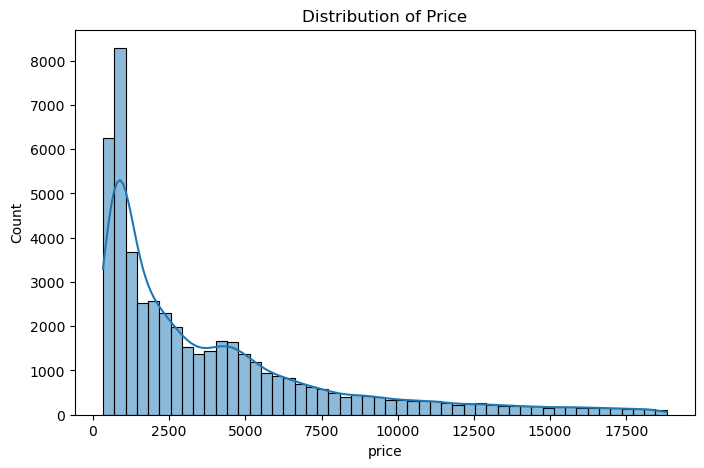

In [24]:
plt.figure(figsize=(8, 5))
sns.histplot(df["price"], bins=50, kde=True)
plt.title("Distribution of Price")
plt.show()

In [25]:
print("Skewness of price:", df["price"].skew())

Skewness of price: 1.6107180158158687


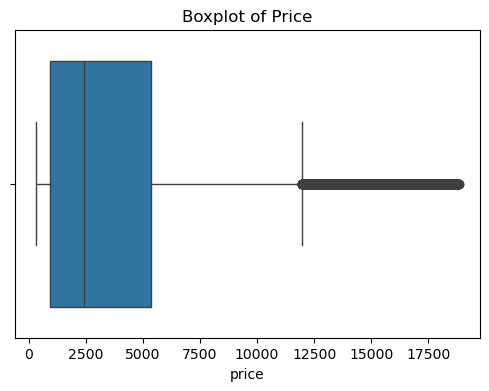

In [26]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=df["price"])
plt.title("Boxplot of Price")
plt.show()

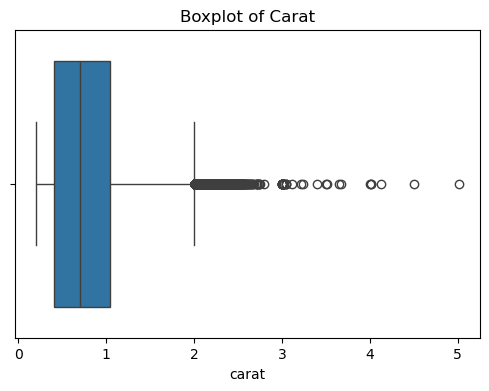

In [27]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=df["carat"])
plt.title("Boxplot of Carat")
plt.show()

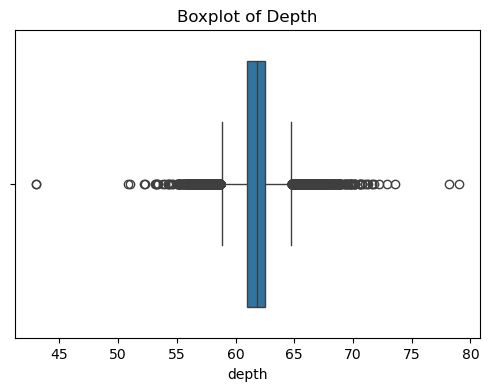

In [28]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=df["depth"])
plt.title("Boxplot of Depth")
plt.show()

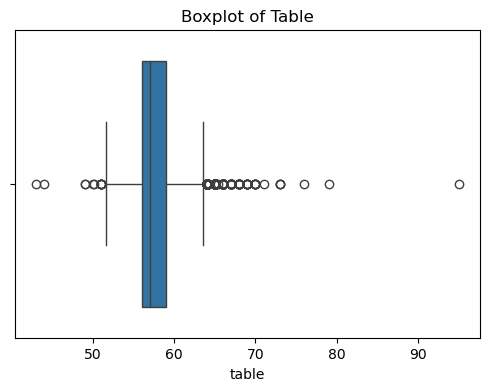

In [29]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=df["table"])
plt.title("Boxplot of Table")
plt.show()

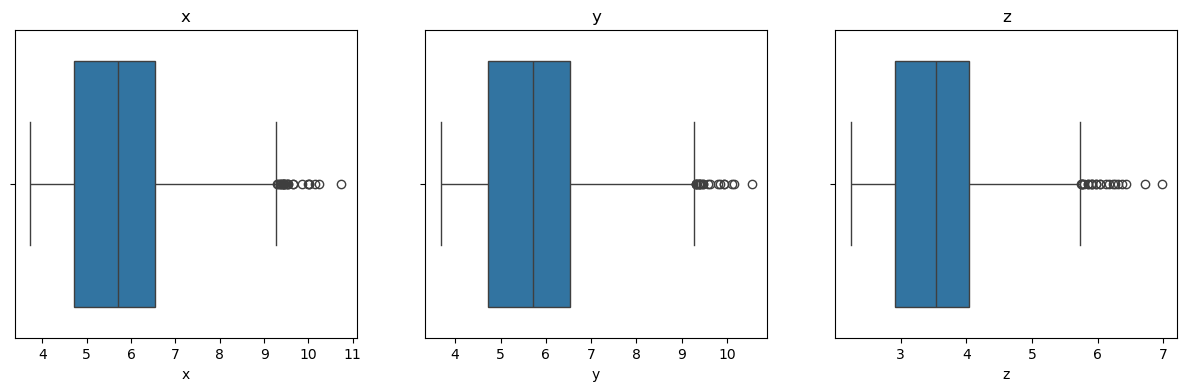

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(x=df["x"], ax=axes[0])
sns.boxplot(x=df["y"], ax=axes[1])
sns.boxplot(x=df["z"], ax=axes[2])
axes[0].set_title("x")
axes[1].set_title("y")
axes[2].set_title("z")
plt.show()

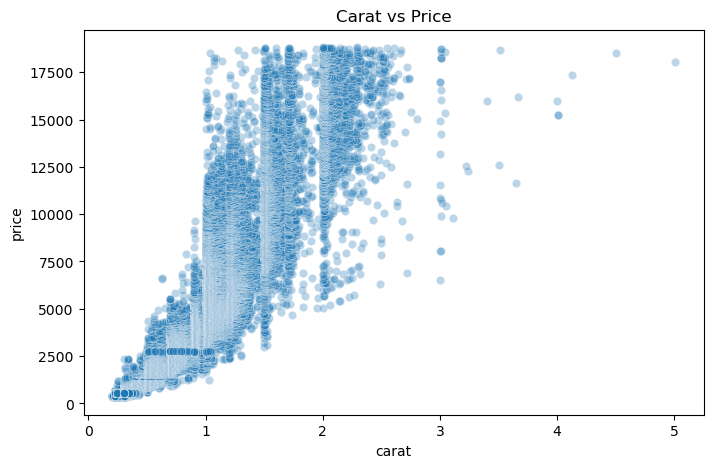

In [33]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df["carat"], y=df["price"], alpha=0.3)
plt.title("Carat vs Price")
plt.show()

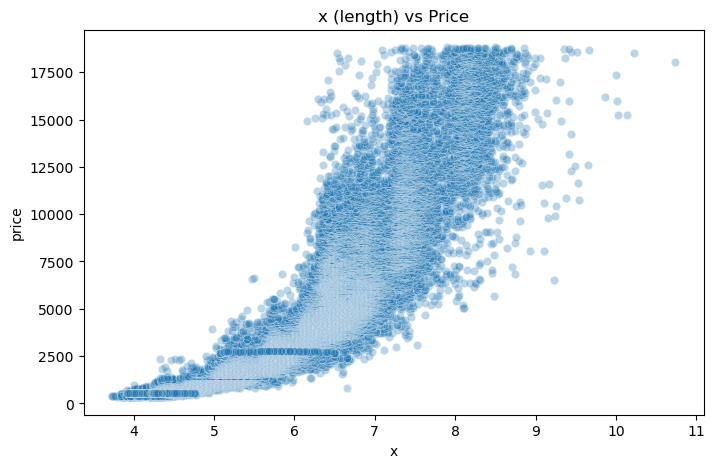

In [34]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df["x"], y=df["price"], alpha=0.3)
plt.title("x (length) vs Price")
plt.show()

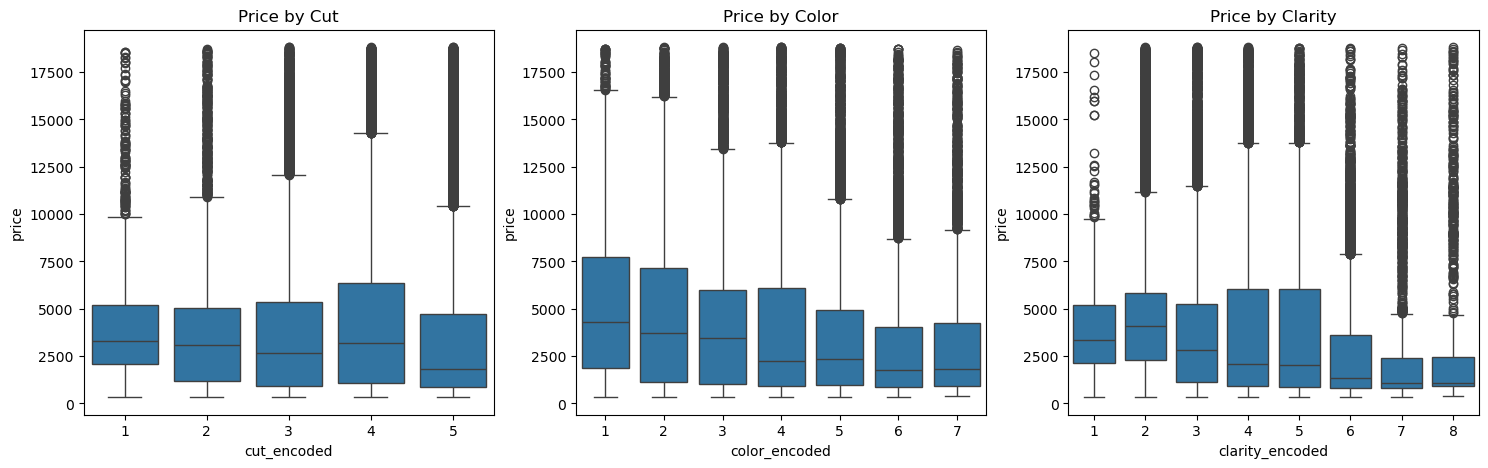

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(x=df["cut_encoded"], y=df["price"], ax=axes[0])
sns.boxplot(x=df["color_encoded"], y=df["price"], ax=axes[1])
sns.boxplot(x=df["clarity_encoded"], y=df["price"], ax=axes[2])
axes[0].set_title("Price by Cut")
axes[1].set_title("Price by Color")
axes[2].set_title("Price by Clarity")
plt.show()

In [36]:
Q1 = df["carat"].quantile(0.25)
Q3 = df["carat"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["carat"] < lower_bound) | (df["carat"] > upper_bound)]
print("Number of outliers in carat:", outliers.shape[0])

Number of outliers in carat: 1752


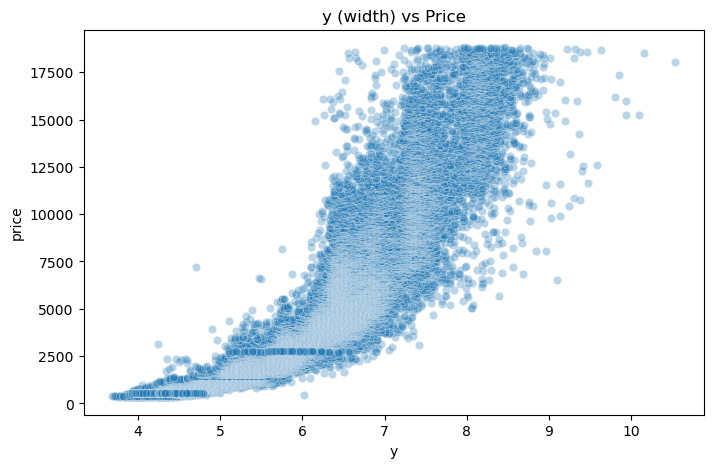

In [37]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df["y"], y=df["price"], alpha=0.3)
plt.title("y (width) vs Price")
plt.show()

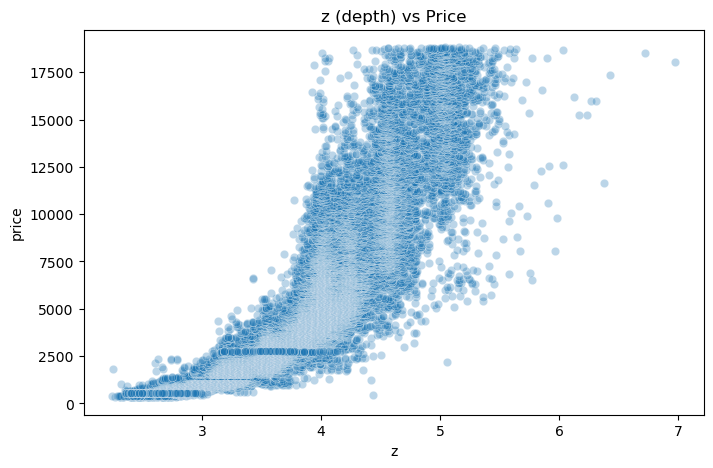

In [38]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df["z"], y=df["price"], alpha=0.3)
plt.title("z (depth) vs Price")
plt.show()

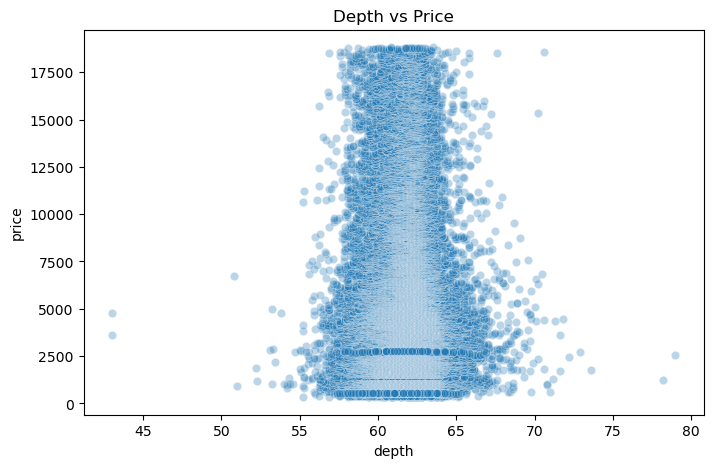

In [39]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df["depth"], y=df["price"], alpha=0.3)
plt.title("Depth vs Price")
plt.show()